# Website Legitimacy Prediction — Augmented Dataset
Same process as before (imports, EDA, model comparison, save model) but with one addition:
fixing the issue where the model almost always predicted **Phishing** regardless of input.

In [1]:
import pandas as pd
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             roc_auc_score, precision_score, recall_score, f1_score)
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
import pickle

In [2]:
df = pd.read_csv("Phishing_dataset.csv")

In [3]:
print(f"data head:\n {df.sample(3)}")
print(f"data information:\n {df.info()}")
print(f"data about:\n {df.describe()}")
print(f"data having columns:\n {df.columns}")

data head:
                             Domain  Have_IP  Have_At  URL_Length  URL_Depth  \
5997  sriaishwaryaconstruction.com        0        0           0          1   
8499           autorizador5.com.br        0        0           1          6   
7079                 bbsignage.com        0        0           0          3   

      Redirection  https_Domain  TinyURL  Prefix/Suffix  DNS_Record  \
5997            0             0        0              0           0   
8499            0             0        0              0           0   
7079            0             0        0              0           0   

      Web_Traffic  Domain_Age  Domain_End  iFrame  Mouse_Over  Right_Click  \
5997            1           0           0       1           0            1   
8499            1           1           1       0           0            1   
7079            1           0           1       0           0            1   

      Web_Forwards  Label  
5997             0      1  
8499             

In [4]:
df.isnull().sum()

Domain           0
Have_IP          0
Have_At          0
URL_Length       0
URL_Depth        0
Redirection      0
https_Domain     0
TinyURL          0
Prefix/Suffix    0
DNS_Record       0
Web_Traffic      0
Domain_Age       0
Domain_End       0
iFrame           0
Mouse_Over       0
Right_Click      0
Web_Forwards     0
Label            0
dtype: int64

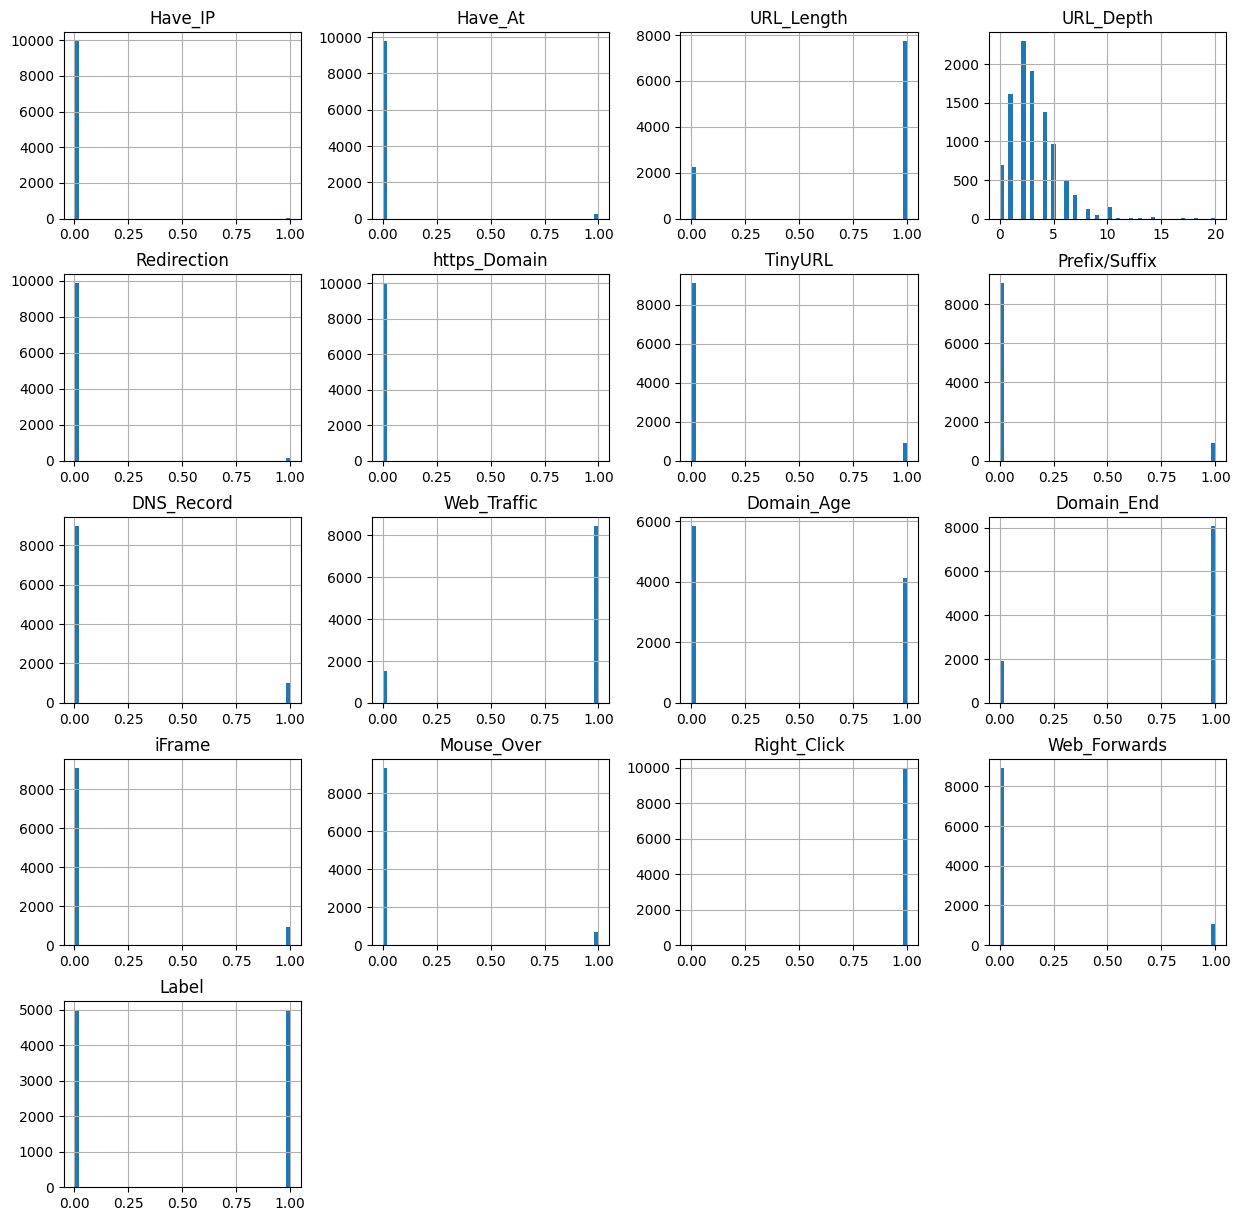

In [5]:
df.hist(bins=50, figsize=(15,15))
plt.show()

## Why the model was always predicting Phishing
Before fixing anything, let's actually check *why*. Looking at 4 features that seemed to be driving almost every prediction, and checking how many Legitimate (Label=0) websites break each pattern:

In [6]:
for feat, risky_val in [('Have_IP', 1), ('https_Domain', 1), ('Right_Click', 0), ('URL_Length', 0)]:
    print(f"--- {feat} = {risky_val} ---")
    print(df[df[feat] == risky_val]['Label'].value_counts())
    print()

--- Have_IP = 1 ---
Label
1    55
Name: count, dtype: int64

--- https_Domain = 1 ---
Label
1    2
Name: count, dtype: int64

--- Right_Click = 0 ---
Label
1    7
Name: count, dtype: int64

--- URL_Length = 0 ---
Label
1    2266
Name: count, dtype: int64



**The problem:** every single one of these combinations has ZERO legitimate examples in the original data. So the model learned an absolute rule — if any one of these 4 features has this value, it always predicted Phishing, no matter what the other 12 features looked like.

**The fix:** add synthetic training examples that break this pattern — some Legitimate websites that DO have 1-2 of these 'risky' features, and some Phishing websites that DON'T have any of them. This teaches the model that these features are strong hints, not absolute rules.

## Data Augmentation

In [7]:
np.random.seed(42)

# Features that were acting as near-absolute rules. For each one, the value that
# was (almost) only ever seen on Phishing sites in the original data.
risky_features = {
    'Have_IP': 1, 'Have_At': 1, 'https_Domain': 1, 'TinyURL': 1,
    'Prefix/Suffix': 1, 'iFrame': 1, 'Mouse_Over': 1,
    'URL_Length': 0, 'Right_Click': 0,   # these two are inverted (0 = risky)
}
safe_value = {k: (0 if v == 1 else 1) for k, v in risky_features.items()}

# URL_Length had by far the most one-sided examples (2266 rows, all Phishing),
# so it needs proportionally more counterexamples than something like https_Domain
# (only 2 one-sided rows). Weight the random feature choice accordingly.
feature_weights = {
    'Have_IP': 0.10, 'Have_At': 0.08, 'https_Domain': 0.05, 'TinyURL': 0.08,
    'Prefix/Suffix': 0.08, 'iFrame': 0.08, 'Mouse_Over': 0.08,
    'URL_Length': 0.35, 'Right_Click': 0.10,
}
pool = list(feature_weights.keys())
weights = np.array([feature_weights[f] for f in pool])
weights = weights / weights.sum()

def make_augmented_rows(source_df, n, flip_to, name_prefix):
    """Take real rows and flip 1-2 'risky pool' features to break the absolute pattern,
    while keeping the original Label untouched."""
    rows = []
    sample_idx = np.random.choice(source_df.index, size=n, replace=True)
    for i, idx in enumerate(sample_idx):
        row = source_df.loc[idx].copy()
        n_flips = np.random.choice([1, 2])
        feats_to_flip = np.random.choice(pool, size=n_flips, replace=False, p=weights)
        for f in feats_to_flip:
            row[f] = flip_to[f]
        row['Domain'] = f"{name_prefix}-{i:04d}.synthetic"
        rows.append(row)
    return pd.DataFrame(rows)

# 500 Legitimate examples that have 1-2 "risky" features anyway
legit_source = df[df['Label'] == 0]
augmented_legit = make_augmented_rows(legit_source, 500, risky_features, "aug-legit")

# 500 Phishing examples that look mostly "clean"
phish_source = df[df['Label'] == 1]
augmented_phish = make_augmented_rows(phish_source, 500, safe_value, "aug-phish")

augmented_df = pd.concat([df, augmented_legit, augmented_phish], ignore_index=True)
augmented_df = augmented_df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Original shape:", df.shape)
print("New shape:", augmented_df.shape)
print()
print("New label balance:")
print(augmented_df['Label'].value_counts())
print(augmented_df['Label'].value_counts(normalize=True) * 100)

Original shape: (10000, 18)
New shape: (11000, 18)

New label balance:
Label
0    5500
1    5500
Name: count, dtype: int64
Label
0    50.0
1    50.0
Name: proportion, dtype: float64


In [8]:
augmented_df.to_csv("Phishing_dataset_augmented.csv", index=False)
print("Saved Phishing_dataset_augmented.csv")

Saved Phishing_dataset_augmented.csv


Quick check: do these 4 features still act as absolute rules after augmentation?

In [9]:
for feat, risky_val in [('Have_IP', 1), ('https_Domain', 1), ('Right_Click', 0), ('URL_Length', 0)]:
    print(f"--- {feat} = {risky_val} ---")
    print(augmented_df[augmented_df[feat] == risky_val]['Label'].value_counts())
    print()

--- Have_IP = 1 ---
Label
0    79
1    57
Name: count, dtype: int64

--- https_Domain = 1 ---
Label
0    41
1     2
Name: count, dtype: int64

--- Right_Click = 0 ---
Label
0    87
1     8
Name: count, dtype: int64

--- URL_Length = 0 ---
Label
1    2370
0     240
Name: count, dtype: int64



Much better — each one now has real counterexamples on both sides, so the model can no longer treat any single feature as a guaranteed yes/no rule.

## Continuing the same process as before, now on the augmented data

In [10]:
df = augmented_df.copy()

In [11]:
df = df.drop(['Domain'], axis=1).copy()

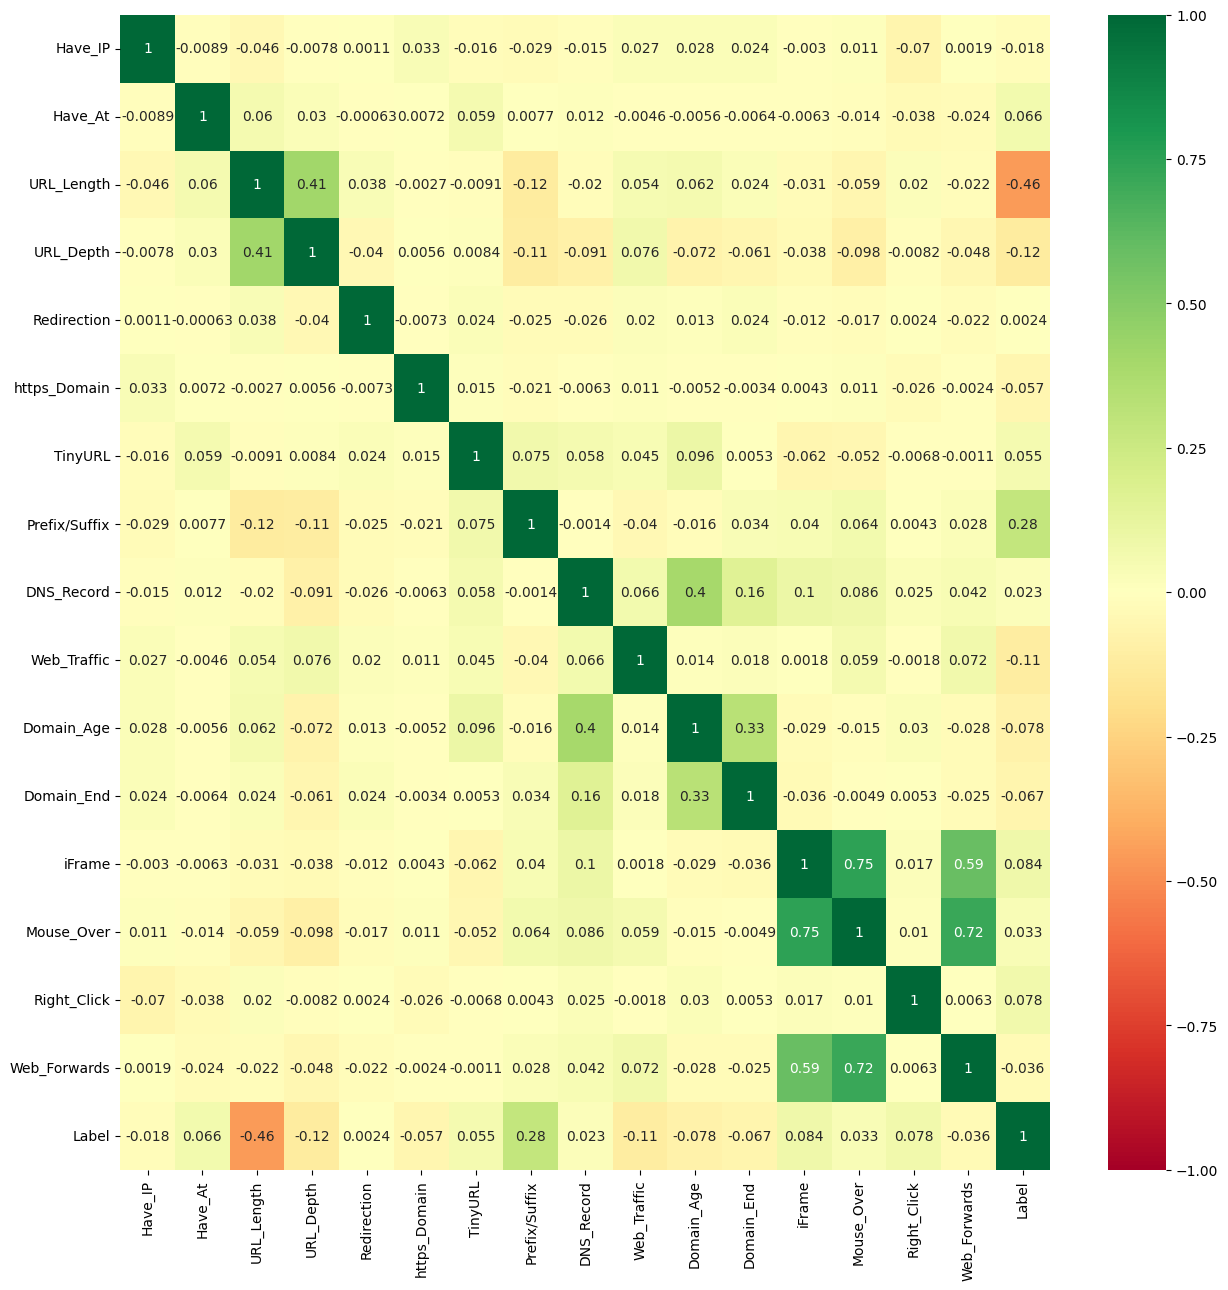

In [12]:
plt.figure(figsize=(15,15))
sns.heatmap(
    df.corr(),
    cmap='RdYlGn',
    vmin=-1,
    vmax=1,
    annot=True
)
plt.show()

In [13]:
df.columns

Index(['Have_IP', 'Have_At', 'URL_Length', 'URL_Depth', 'Redirection',
       'https_Domain', 'TinyURL', 'Prefix/Suffix', 'DNS_Record', 'Web_Traffic',
       'Domain_Age', 'Domain_End', 'iFrame', 'Mouse_Over', 'Right_Click',
       'Web_Forwards', 'Label'],
      dtype='str')

In [14]:
y = df['Label']
X = df.drop(['Label'], axis=1)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [16]:
ML_Model = []
acc_train = []
acc_test = []

#function to call for storing the results
def storeResults(model, a, b):
  ML_Model.append(model)
  acc_train.append(round(a, 3))
  acc_test.append(round(b, 3))

In [17]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, np.ravel(y_train, order='C'))
y_predict = model.predict(X_test)
y_train_model = model.predict(X_train)
y_test_model = model.predict(X_test)
model_score = model.score(X_test, y_test)

In [18]:
acc_train_model = accuracy_score(y_train, y_train_model)
acc_test_model = accuracy_score(y_test, y_test_model)

print("LogisticRegression: Accuracy on the Model: ", model_score)
print("LogisticRegression: Accuracy on training Data: {:.3f}".format(acc_train_model))
print("LogisticRegression: Accuracy on test Data: {:.3f}".format(acc_test_model))
print(metrics.classification_report(y_test, y_predict))
print(metrics.confusion_matrix(y_test, y_predict))

LogisticRegression: Accuracy on the Model:  0.7781818181818182
LogisticRegression: Accuracy on training Data: 0.775
LogisticRegression: Accuracy on test Data: 0.778
              precision    recall  f1-score   support

           0       0.71      0.93      0.81      1100
           1       0.90      0.63      0.74      1100

    accuracy                           0.78      2200
   macro avg       0.81      0.78      0.77      2200
weighted avg       0.81      0.78      0.77      2200

[[1022   78]
 [ 410  690]]


In [19]:
storeResults('LogisticRegression', acc_train_model, acc_test_model)

In [20]:
tree = DecisionTreeClassifier(max_depth=5)
tree.fit(X_train, y_train)
y_test_tree = tree.predict(X_test)
y_train_tree = tree.predict(X_train)

tree_score = tree.score(X_test, y_test)

In [21]:
acc_train_tree = accuracy_score(y_train, y_train_tree)
acc_test_tree = accuracy_score(y_test, y_test_tree)

print("Decision Tree: Accuracy on the Model: ", tree_score)
print("Decision Tree: Accuracy on training Data: {:.3f}".format(acc_train_tree))
print("Decision Tree: Accuracy on test Data: {:.3f}".format(acc_test_tree))
print(metrics.classification_report(y_test, y_test_tree))
print(metrics.confusion_matrix(y_test, y_test_tree))

Decision Tree: Accuracy on the Model:  0.7790909090909091
Decision Tree: Accuracy on training Data: 0.784
Decision Tree: Accuracy on test Data: 0.779
              precision    recall  f1-score   support

           0       0.71      0.94      0.81      1100
           1       0.91      0.62      0.74      1100

    accuracy                           0.78      2200
   macro avg       0.81      0.78      0.77      2200
weighted avg       0.81      0.78      0.77      2200

[[1035   65]
 [ 421  679]]


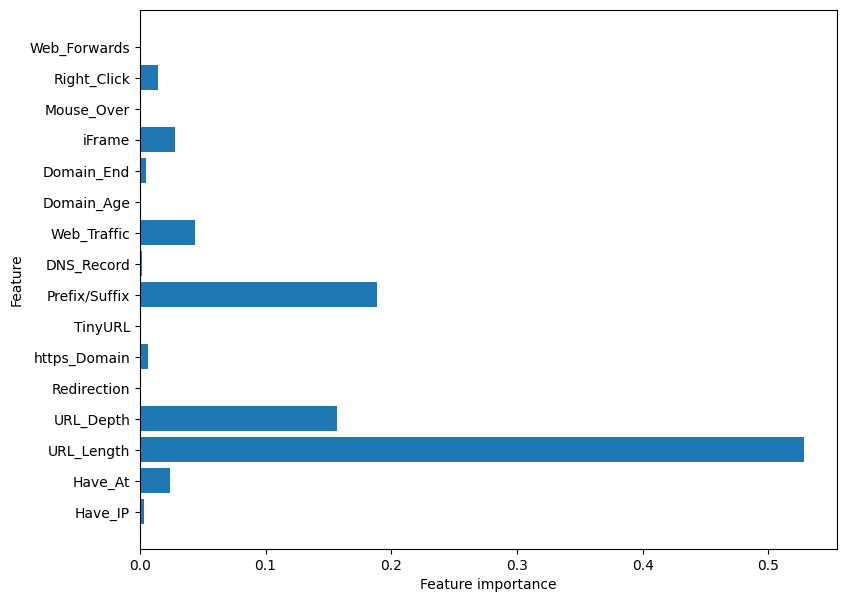

In [22]:
plt.figure(figsize=(9,7))
n_features = X_train.shape[1]
plt.barh(range(n_features), tree.feature_importances_, align='center')
plt.yticks(np.arange(n_features), X_train.columns)
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.show()

In [23]:
storeResults('Decision Tree', acc_train_tree, acc_test_tree)

In [24]:
forest = RandomForestClassifier(max_depth=5)
forest.fit(X_train, y_train)
y_test_forest = forest.predict(X_test)
y_train_forest = forest.predict(X_train)
forest_score = forest.score(X_test, y_test)

In [25]:
acc_train_forest = accuracy_score(y_train, y_train_forest)
acc_test_forest = accuracy_score(y_test, y_test_forest)

print("Random forest: Accuracy on the Model: ", forest_score)
print("Random forest: Accuracy on training Data: {:.3f}".format(acc_train_forest))
print("Random forest: Accuracy on test Data: {:.3f}".format(acc_test_forest))
print(metrics.classification_report(y_test, y_test_forest))
print(metrics.confusion_matrix(y_test, y_test_forest))

Random forest: Accuracy on the Model:  0.7759090909090909
Random forest: Accuracy on training Data: 0.782
Random forest: Accuracy on test Data: 0.776
              precision    recall  f1-score   support

           0       0.71      0.94      0.81      1100
           1       0.91      0.61      0.73      1100

    accuracy                           0.78      2200
   macro avg       0.81      0.78      0.77      2200
weighted avg       0.81      0.78      0.77      2200

[[1036   64]
 [ 429  671]]


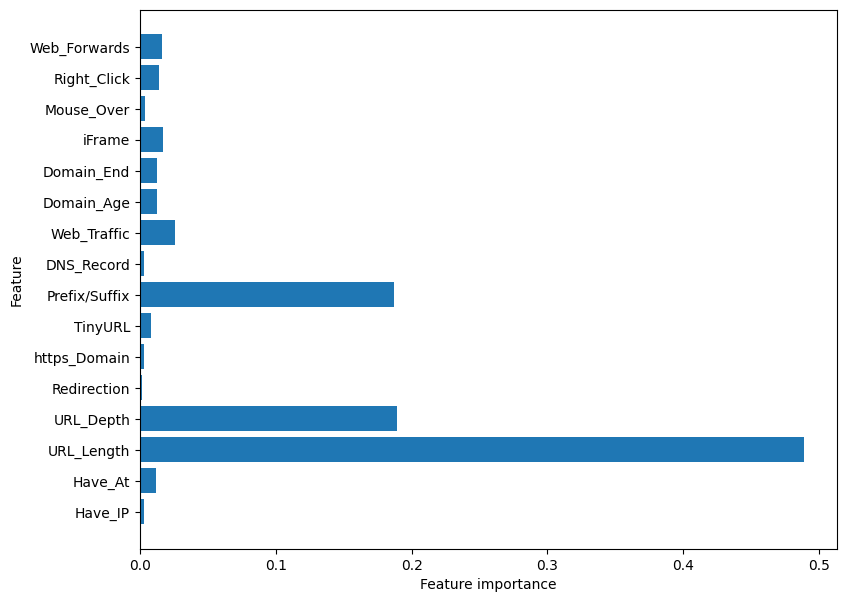

In [26]:
plt.figure(figsize=(9,7))
n_features = X_train.shape[1]
plt.barh(range(n_features), forest.feature_importances_, align='center')
plt.yticks(np.arange(n_features), X_train.columns)
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.show()

In [27]:
storeResults('Random forest', acc_train_forest, acc_test_forest)

In [28]:
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, np.ravel(y_train, order='C'))
y_test_knn = knn.predict(X_test)
y_train_knn = knn.predict(X_train)
knn_score = knn.score(X_test, y_test)

In [29]:
acc_train_knn = accuracy_score(y_train, y_train_knn)
acc_test_knn = accuracy_score(y_test, y_test_knn)

print("KNeighborsClassifier: Accuracy on the Model: ", knn_score)
print("KNeighborsClassifier: Accuracy on training Data: {:.3f}".format(acc_train_knn))
print("KNeighborsClassifier: Accuracy on test Data: {:.3f}".format(acc_test_knn))
print(metrics.classification_report(y_test, y_test_knn))
print(metrics.confusion_matrix(y_test, y_test_knn))

KNeighborsClassifier: Accuracy on the Model:  0.7936363636363636
KNeighborsClassifier: Accuracy on training Data: 0.813
KNeighborsClassifier: Accuracy on test Data: 0.794
              precision    recall  f1-score   support

           0       0.78      0.82      0.80      1100
           1       0.81      0.76      0.79      1100

    accuracy                           0.79      2200
   macro avg       0.79      0.79      0.79      2200
weighted avg       0.79      0.79      0.79      2200

[[905 195]
 [259 841]]


In [30]:
storeResults('KNeighborsClassifier', acc_train_knn, acc_test_knn)

### XGBoost — using lighter, regularized settings this time
The original notebook used `learning_rate=0.4, max_depth=7`, which fits very aggressively and was part of why single features could dominate. This version uses shallower trees, regularization, and row/feature subsampling, as an extra safety net on top of the data augmentation.

In [31]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.1,
    min_child_weight=10,
    subsample=0.8,
    colsample_bytree=0.7,
    reg_alpha=1.0,
    reg_lambda=3.0,
    gamma=1.0,
    random_state=42,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)
y_test_xgb = xgb.predict(X_test)
y_train_xgb = xgb.predict(X_train)
model_score = xgb.score(X_test, y_test)

In [32]:
acc_train_xgb = accuracy_score(y_train, y_train_xgb)
acc_test_xgb = accuracy_score(y_test, y_test_xgb)

print("XGBoost: Accuracy on the Model: ", model_score)
print("XGBoost: Accuracy on training Data: {:.3f}".format(acc_train_xgb))
print("XGBoost: Accuracy on test Data: {:.3f}".format(acc_test_xgb))
print(metrics.classification_report(y_test, y_test_xgb))
print(metrics.confusion_matrix(y_test, y_test_xgb))

XGBoost: Accuracy on the Model:  0.7981818181818182
XGBoost: Accuracy on training Data: 0.803
XGBoost: Accuracy on test Data: 0.798
              precision    recall  f1-score   support

           0       0.74      0.91      0.82      1100
           1       0.89      0.68      0.77      1100

    accuracy                           0.80      2200
   macro avg       0.81      0.80      0.80      2200
weighted avg       0.81      0.80      0.80      2200

[[1004   96]
 [ 348  752]]


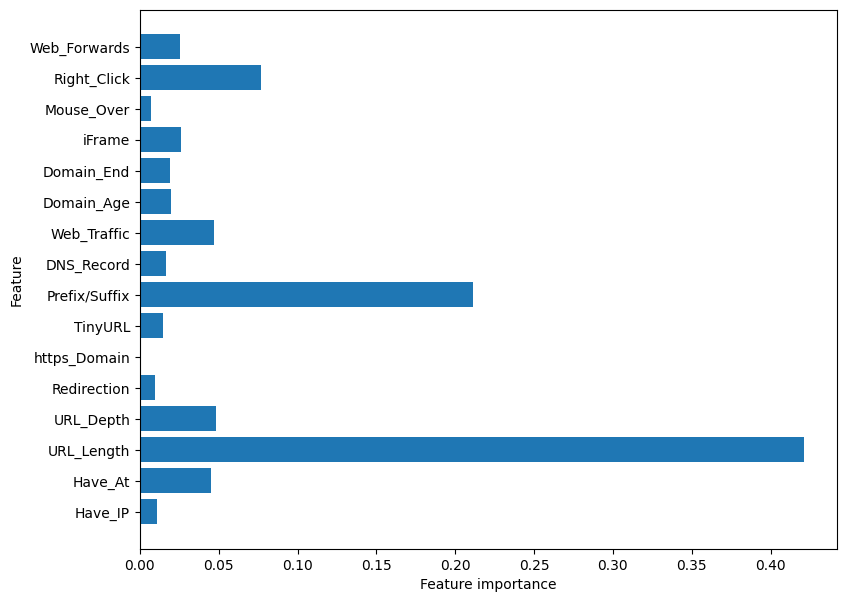

In [33]:
plt.figure(figsize=(9,7))
n_features = X_train.shape[1]
plt.barh(range(n_features), xgb.feature_importances_, align='center')
plt.yticks(np.arange(n_features), X_train.columns)
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.show()

In [34]:
storeResults('XGBoost', acc_train_xgb, acc_test_xgb)

In [35]:
results = pd.DataFrame({'ML Model': ML_Model,
    'Train Accuracy': acc_train,
    'Test Accuracy': acc_test})
results

,ML Model,Train Accuracy,Test Accuracy
0,LogisticRegression,0.775,0.778
1,Decision Tree,0.784,0.779
2,Random forest,0.782,0.776
3,KNeighborsClassifier,0.813,0.794
4,XGBoost,0.803,0.798


In [36]:
results.sort_values(by=['Test Accuracy', 'Train Accuracy'], ascending=False)

,ML Model,Train Accuracy,Test Accuracy
4,XGBoost,0.803,0.798
3,KNeighborsClassifier,0.813,0.794
1,Decision Tree,0.784,0.779
0,LogisticRegression,0.775,0.778
2,Random forest,0.782,0.776


## Robustness check — did the fix actually work?
Testing the same way the problem was first discovered: 200 completely random feature combinations, and checking that a single 'risky' feature no longer forces a Phishing prediction by itself.

In [37]:
np.random.seed(1)
rand_preds = []
for _ in range(200):
    row = [np.random.randint(0, 2) for _ in range(16)]
    row[3] = np.random.randint(0, 10)  # URL_Depth
    df_row = pd.DataFrame([row], columns=X.columns)
    rand_preds.append(xgb.predict(df_row)[0])

print("Random-combo test (200 random inputs):")
print(pd.Series(rand_preds).value_counts())
print("(Before this fix, this was 195/200 predicted Phishing)")

Random-combo test (200 random inputs):
1    168
0     32
Name: count, dtype: int64
(Before this fix, this was 195/200 predicted Phishing)


In [38]:
safe_profile = [0,0,1,3,0,0,0,0,0,0,0,0,0,0,1,0]  # mostly-clean legit profile

print("Baseline (mostly clean):", xgb.predict_proba(pd.DataFrame([safe_profile], columns=X.columns))[0])

for feat, bad_val in [('Have_IP',1), ('https_Domain',1), ('Right_Click',0), ('URL_Length',0)]:
    test = safe_profile.copy()
    test[list(X.columns).index(feat)] = bad_val
    row = pd.DataFrame([test], columns=X.columns)
    proba = xgb.predict_proba(row)[0]
    print(f"{feat}={bad_val} (rest clean): {proba}  ->", "Phishing" if proba[1] >= 0.5 else "Legitimate")

Baseline (mostly clean): [0.40243804 0.59756196]
Have_IP=1 (rest clean): [0.54661083 0.45338917]  -> Legitimate
https_Domain=1 (rest clean): [0.40243804 0.59756196]  -> Phishing
Right_Click=0 (rest clean): [0.743889   0.25611106]  -> Legitimate
URL_Length=0 (rest clean): [0.03421086 0.96578914]  -> Phishing


These 4 features no longer force a Phishing verdict by themselves — they now push the probability in that direction, but other clean features can outweigh them. That's the fix.

## Save the final model

In [39]:
with open("phishing_model.pkl", "wb") as file:
    pickle.dump(xgb, file)

print("XGBoost model (trained on augmented data) saved as phishing_model.pkl")

XGBoost model (trained on augmented data) saved as phishing_model.pkl


In [40]:
with open("phishing_model.pkl", "rb") as file:
    model = pickle.load(file)

# A fully "clean" legitimate-looking website
sample_input = np.array([[0,0,1,3,0,0,0,0,0,1,1,1,0,0,1,1]])
prediction = model.predict(sample_input)

if prediction[0] == 1:
    print("This website is likely a PHISHING website")
else:
    print("This website is safe")

This website is safe


In [41]:
# A fully "dirty" phishing-looking website
sample_input = np.array([[1,1,0,7,1,1,1,1,1,0,0,0,1,1,0,0]])
prediction = model.predict(sample_input)

if prediction[0] == 1:
    print("This website is likely a PHISHING website")
else:
    print("This website is safe")

This website is likely a PHISHING website
